# Question 2 Clustering: Full Trait Model

This notebook clusters dog breeds using the full set of numeric AKC trait scores, then compares those clusters to popularity tier and AKC group without regrouping the traits.

In [1]:
from pathlib import Path
import sys

import pandas as pd

for base_dir in [Path.cwd(), *Path.cwd().parents]:
    if (base_dir / "data").exists() and (base_dir / "models").exists():
        PROJECT_ROOT = base_dir
        break
else:
    raise FileNotFoundError("Could not find project root with data/ and models/ folders.")

sys.path.insert(0, str(PROJECT_ROOT))

from models.clustering.kmeans import kmeans_main
from models.clustering.clustering_analysis_utils import (
    akc_group_traits_table,
    cluster_summary_with_akc,
    plot_cluster_composition,
    predictions_output,
)
from models.clustering.evaluation import print_cluster_report

In [2]:
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "breed_clustering_full.csv"
PREDICTION_OUTPUT_PATH = PROJECT_ROOT / "results" / "question2" / "clustering_full_predictions.csv"

## Cluster Summary on AKC Groups

In [3]:
data, labels, centroids, ground_truth = kmeans_main(DATA_PATH, 7, 0.000000001, 17)

PREDICTION_OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
prediction_results = predictions_output(DATA_PATH, labels, PREDICTION_OUTPUT_PATH, centroids)

print_cluster_report(data, labels, ground_truth)
cluster_summary = cluster_summary_with_akc(prediction_results, data, labels, DATA_PATH, centroids)
cluster_summary


Overall Metrics
Overall silhouette score: 0.1
Rand Index: 0.77
Average radius / average intercluster distance: 1.27


Trait Cluster,Cluster 1,Cluster 2,Cluster 3,Cluster 4,Cluster 5,Cluster 6,Cluster 7
Metric,,,,,,,
Cluster Size,29,31,32,21,29,34,26
Most Common AKC Group,Terrier Group,Hound Group,Hound Group,Working Group,Herding Group,Sporting Group,Herding Group
Most Common AKC Group Count,10,11,10,12,8,14,10
Predicted AKC Group,Terrier Group,Hound Group,Hound Group,Working Group,Herding Group,Sporting Group,Herding Group
Distance To Predicted AKC Group,1.27,1.48,1.79,1.56,1.62,1.25,1.9
AKC Rand Index,0.68,0.67,0.66,0.75,0.65,0.69,0.69
Silhouette Score,0.16,0.06,0.09,0.14,0.06,0.1,0.11
Radius,3.82,3.55,3.76,4.21,3.87,3.46,3.78


### Cluster Centroids vs AKC Group Traits Averages

In [4]:
cluster_traits = pd.DataFrame(
    centroids.round(2).T,
    index=data.columns,
    columns=[f"Cluster {i}" for i in range(1, centroids.shape[0] + 1)]
)
cluster_traits.index.name = "Trait"
cluster_traits

,Cluster 1,Cluster 2,Cluster 3,Cluster 4,Cluster 5,Cluster 6,Cluster 7
Trait,,,,,,,
Affectionate With Family,4.90,4.45,4.50,4.52,4.97,4.91,3.12
Good With Young Children,3.07,3.61,4.81,3.43,3.79,4.88,3.04
Good With Other Dogs,2.86,3.68,4.66,3.10,3.38,3.88,2.88
Shedding Level,2.24,1.81,2.84,3.05,2.72,3.00,2.54
Coat Grooming Frequency,2.52,1.81,2.50,1.81,2.24,2.15,2.81
Drooling Level,1.45,1.19,1.75,3.57,1.52,2.12,1.23
Openness To Strangers,3.17,3.06,3.78,3.05,4.07,4.06,2.92
Playfulness Level,3.45,3.48,3.62,3.10,4.21,4.26,3.15
Watchdog/Protective Nature,4.31,3.03,2.91,4.48,4.21,3.56,3.92


In [5]:
group_traits = akc_group_traits_table(DATA_PATH)
group_traits

AKC Group,Herding Group,Hound Group,Non-Sporting Group,Sporting Group,Terrier Group,Toy Group,Working Group
Trait,,,,,,,
Affectionate With Family,4.18,4.25,4.85,4.64,4.68,4.76,4.44
Good With Young Children,3.70,3.78,4.00,4.12,3.97,3.57,3.91
Good With Other Dogs,3.36,4.22,3.40,3.91,2.94,3.76,3.22
Shedding Level,2.82,2.50,2.50,2.70,2.16,2.33,2.97
Coat Grooming Frequency,2.42,1.66,2.50,2.33,2.35,2.57,2.22
Drooling Level,1.55,1.75,1.65,2.12,1.29,1.10,2.66
Openness To Strangers,3.12,3.22,3.80,3.73,3.65,3.81,3.31
Playfulness Level,3.64,3.38,3.80,3.85,3.68,3.81,3.53
Watchdog/Protective Nature,3.91,3.06,3.80,3.18,3.94,3.62,4.53


### How well do trait-based clusters line up with AKC Groups?

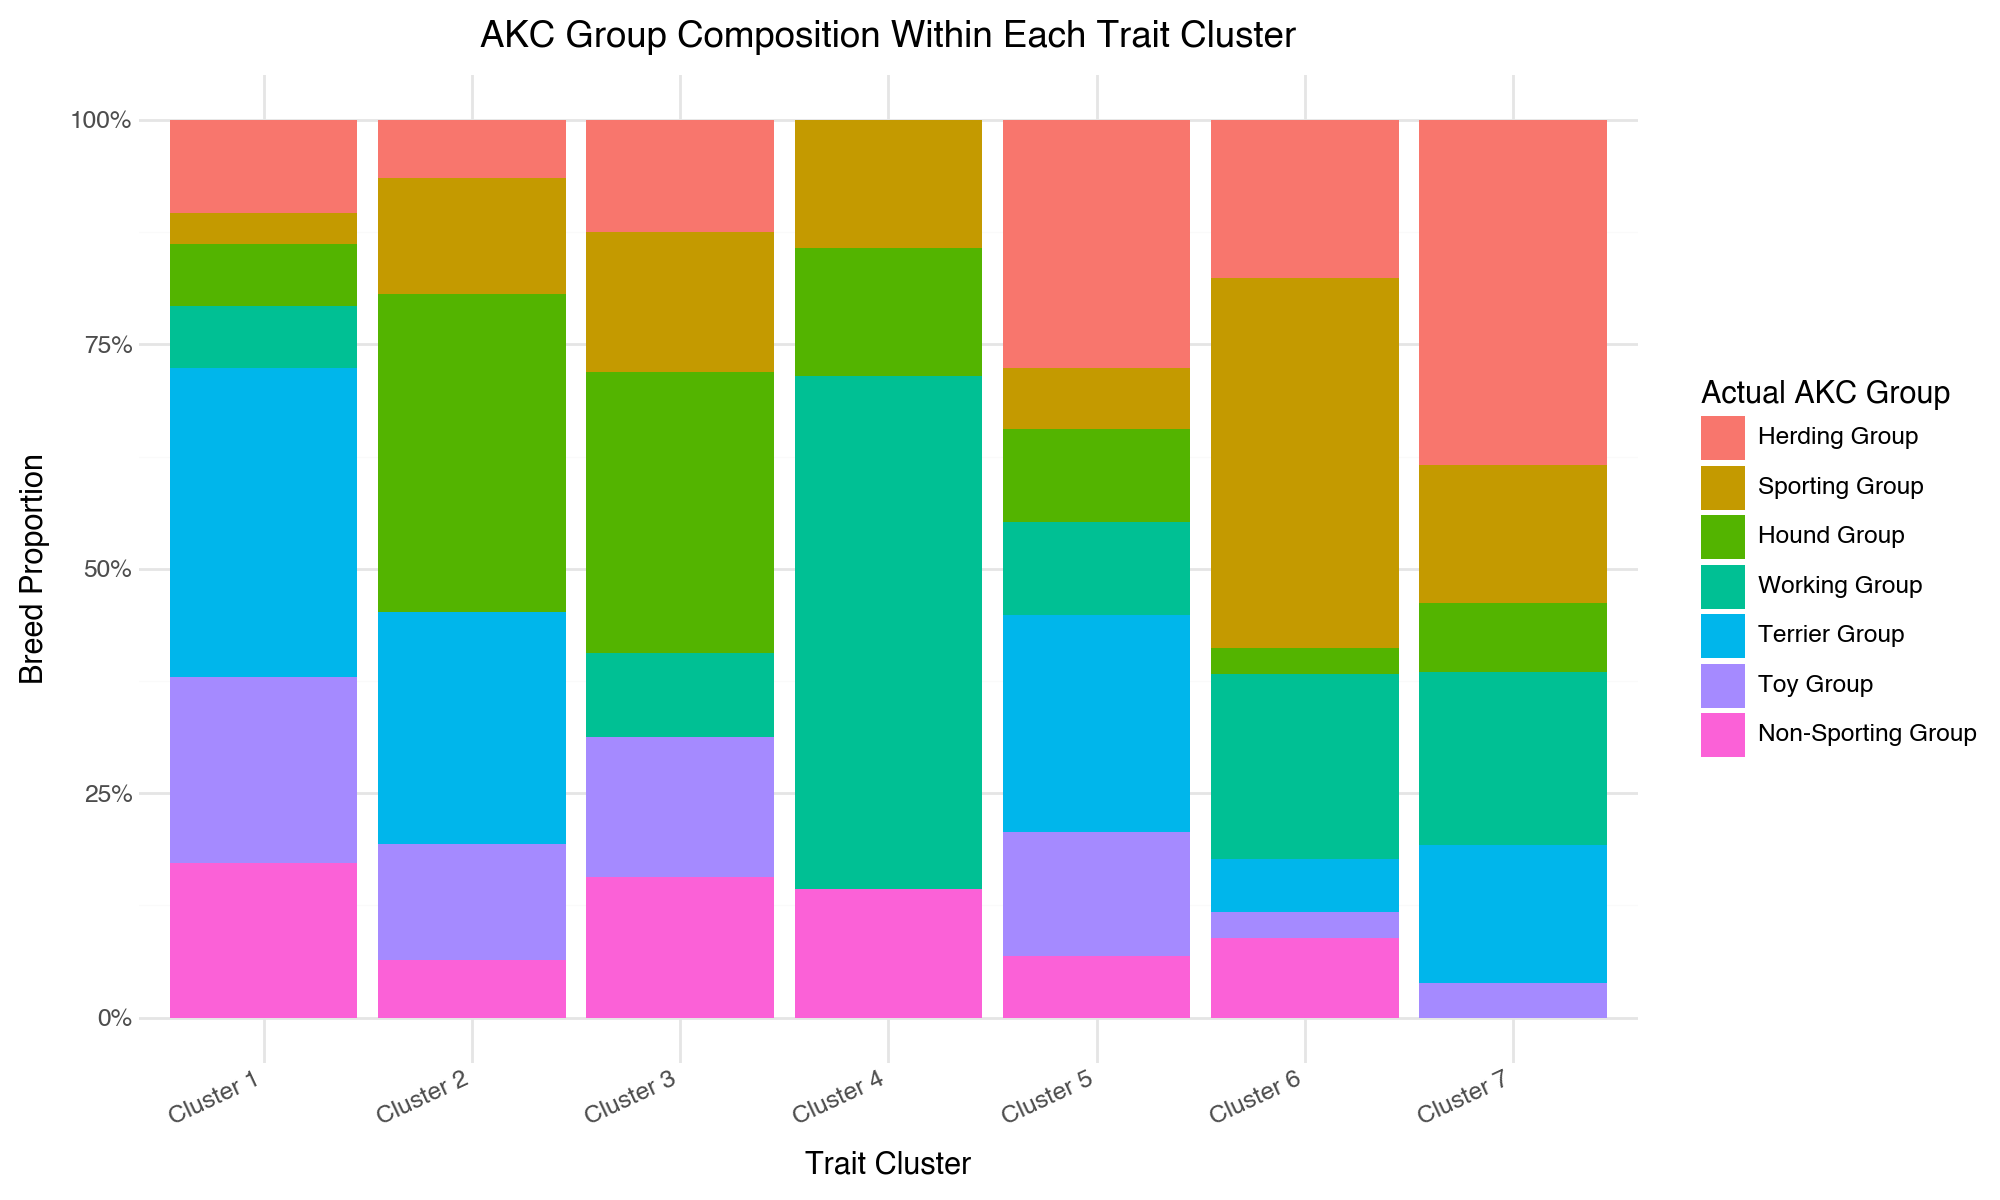

In [6]:
plot_cluster_composition(prediction_results)

## Prediction Output

This table saves each breed's assigned cluster with its average rank, popularity tier, and AKC group.

In [7]:
prediction_results.to_csv(PREDICTION_OUTPUT_PATH, index=False)
prediction_results

,Breed,Trait Cluster,Predicted AKC Group,Actual AKC Group,Distance To Predicted AKC Group,Correct AKC Prediction
0,Affenpinscher,Cluster 7,Herding Group,Toy Group,1.90,False
1,Afghan Hound,Cluster 7,Herding Group,Hound Group,1.90,False
2,Airedale Terrier,Cluster 7,Herding Group,Terrier Group,1.90,False
3,Akita,Cluster 7,Herding Group,Working Group,1.90,False
4,Alaskan Malamute,Cluster 7,Herding Group,Working Group,1.90,False
...,...,...,...,...,...,...
197,Wire Fox Terrier,Cluster 5,Herding Group,Terrier Group,1.62,False
198,Wirehaired Pointing Griffon,Cluster 6,Sporting Group,Sporting Group,1.25,True
199,Wirehaired Vizsla,Cluster 6,Sporting Group,Sporting Group,1.25,True
200,Xoloitzcuintli,Cluster 2,Hound Group,Non-Sporting Group,1.48,False
